Import Required Libraries

In [1]:
# Import NumPy for numerical operations
import numpy as np

# Import Pandas for loading and handling the dataset
import pandas as pd

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import TensorFlow and Keras for building the deep learning model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Import Scikit-learn functions for preprocessing and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Display TensorFlow version to verify the environment
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Load the Dataset

In [2]:

# TASK 1: DATA ACQUISITION AND LOADING


# URL of the Pima Indians Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names of the dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Load the dataset using Pandas
df = pd.read_csv(url, names=columns)

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display the size of the dataset
print("\nDataset Shape:", df.shape)

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape: (768, 9)


Understand the Dataset

In [3]:
# Display information about the dataset
# This shows the number of entries, columns, and data types
print("Dataset Information:")
df.info()

# Check whether the dataset contains missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Display basic statistical information
print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values in Each Column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Diabete

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Preprocessing

In [4]:
# Separate the input features from the target variable
# 'Outcome' is the target:
# 0 = No Diabetes
# 1 = Diabetes

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Display the shapes of X and y
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display the first 5 rows of features
print("\nFirst 5 rows of Features:")
display(X.head())

# Display the first 5 target values
print("\nFirst 5 Target Values:")
display(y.head())

Features (X) shape: (768, 8)
Target (y) shape: (768,)

First 5 rows of Features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



First 5 Target Values:


,Outcome
0,1
1,0
2,1
3,0
4,1


Train-Test Split and Feature Scaling

In [5]:
# ============================================
# TASK 2: TRAIN-TEST SPLIT AND SCALING
# ============================================

# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% of the data is used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler only on the training data
# and transform the training features
X_train = scaler.fit_transform(X_train)

# Use the same scaler to transform the test features
X_test = scaler.transform(X_test)

# Display the shapes of the training and testing data
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (614, 8)
Testing features shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)


 DEEP LEARNING GRID SEARCH

In [6]:
# Function to create a Keras neural network model
# Grid Search will provide different values for
# the parameters of this function.

def create_model(
    learning_rate=0.001,
    init_mode="uniform",
    activation="relu",
    dropout_rate=0.0,
    neurons=16
):
    # Create a Sequential neural network
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        neurons,
        input_shape=(X_train.shape[1],),
        kernel_initializer=init_mode,
        activation=activation
    ))

    # Dropout layer to reduce overfitting
    model.add(Dropout(dropout_rate))

    # Output layer
    # Sigmoid is used because this is a binary classification problem
    model.add(Dense(
        1,
        kernel_initializer=init_mode,
        activation="sigmoid"
    ))

    # Create the Adam optimizer with the selected learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

 SCIKIT-LEARN KERAS WRAPPER

In [7]:
# Install SciKeras for connecting Keras with Scikit-learn
!pip -q install scikeras

# Import the Scikit-learn compatible Keras classifier
from scikeras.wrappers import KerasClassifier

# Create the Keras classifier
# The model will be created by our create_model() function
model = KerasClassifier(
    model=create_model,
    verbose=0
)

print("Keras model successfully wrapped for Scikit-learn.")

Keras model successfully wrapped for Scikit-learn.


DEFINE GRID SEARCH PARAMETERS

In [8]:
# Define the hyperparameter values that Grid Search will test
param_grid = {
    # Number of samples processed before updating model weights
    "batch_size": [16, 32],

    # Number of complete passes through the training data
    "epochs": [50, 100],

    # Learning rate of the Adam optimizer
    "model__learning_rate": [0.001, 0.01],

    # Method used to initialize neural network weights
    "model__init_mode": ["uniform", "normal"],

    # Activation function used in the hidden layer
    "model__activation": ["relu", "tanh"],

    # Dropout rate used for regularization
    "model__dropout_rate": [0.0, 0.2],

    # Number of neurons in the hidden layer
    "model__neurons": [16, 32]
}

# Display all parameters that will be tested
print("Hyperparameters selected for Grid Search:\n")

for parameter, values in param_grid.items():
    print(parameter, ":", values)

Hyperparameters selected for Grid Search:

batch_size : [16, 32]
epochs : [50, 100]
model__learning_rate : [0.001, 0.01]
model__init_mode : ['uniform', 'normal']
model__activation : ['relu', 'tanh']
model__dropout_rate : [0.0, 0.2]
model__neurons : [16, 32]


RUN GRID SEARCH

In [10]:
# Install compatible versions of Scikit-learn and SciKeras
!pip -q install --upgrade scikit-learn scikeras

# Import the Scikit-learn compatible Keras classifier
from scikeras.wrappers import KerasClassifier

# Create the Keras classifier again
model = KerasClassifier(
    model=create_model,
    verbose=0
)

# Check installed versions
import sklearn
import scikeras

print("Scikit-learn version:", sklearn.__version__)
print("SciKeras version:", scikeras.__version__)
print("Keras model successfully wrapped for Scikit-learn.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.2 MB/s eta 0:00:00
Scikit-learn version: 1.6.1
SciKeras version: 0.13.0
Keras model successfully wrapped for Scikit-learn.


In [12]:
# ============================================
# FIX: INSTALL COMPATIBLE VERSIONS
# ============================================

# Install versions that work reliably together
!pip -q install scikit-learn==1.5.2 scikeras==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 95.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


RUN GRID SEARCH

In [14]:
# Import the Scikit-learn compatible Keras classifier
from scikeras.wrappers import KerasClassifier

# Create the Keras classifier
model = KerasClassifier(
    model=create_model,
    verbose=0
)

print("Keras model successfully wrapped.")

Keras model successfully wrapped.


In [15]:
# Check installed package versions

import sklearn
import scikeras

print("Scikit-learn version:", sklearn.__version__)
print("SciKeras version:", scikeras.__version__)

Scikit-learn version: 1.6.1
SciKeras version: 0.13.0


In [21]:
# ============================================
# TASK 3: CUSTOM KERAS-SCIKIT-LEARN WRAPPER
# ============================================

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score


class KerasGridClassifier(BaseEstimator, ClassifierMixin):

    _estimator_type = "classifier"

    def __init__(
        self,
        learning_rate=0.001,
        init_mode="uniform",
        activation="relu",
        dropout_rate=0.0,
        neurons=16,
        batch_size=32,
        epochs=50
    ):
        self.learning_rate = learning_rate
        self.init_mode = init_mode
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.neurons = neurons
        self.batch_size = batch_size
        self.epochs = epochs

    def fit(self, X, y):

        # Store the class labels for Scikit-learn
        self.classes_ = np.unique(y)

        # Create the neural network
        self.model_ = Sequential()

        # Define the input shape
        self.model_.add(
            keras.Input(shape=(X.shape[1],))
        )

        # Add hidden layer
        self.model_.add(
            Dense(
                self.neurons,
                kernel_initializer=self.init_mode,
                activation=self.activation
            )
        )

        # Add dropout regularization
        self.model_.add(
            Dropout(self.dropout_rate)
        )

        # Add output layer for binary classification
        self.model_.add(
            Dense(
                1,
                kernel_initializer=self.init_mode,
                activation="sigmoid"
            )
        )

        # Create Adam optimizer
        optimizer = Adam(
            learning_rate=self.learning_rate
        )

        # Compile the model
        self.model_.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        # Train the model
        self.model_.fit(
            X,
            y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=0
        )

        return self

    def predict(self, X):

        # Generate probability predictions
        probabilities = self.model_.predict(
            X,
            verbose=0
        )

        # Convert probabilities into 0 or 1
        return (probabilities >= 0.5).astype(int).ravel()

    def score(self, X, y):

        # Calculate prediction accuracy
        predictions = self.predict(X)

        return accuracy_score(y, predictions)


print("Corrected Keras-Scikit-learn wrapper created successfully!")

Corrected Keras-Scikit-learn wrapper created successfully!


In [18]:
# ============================================
# CREATE GRID SEARCH MODEL
# ============================================

# Create our custom Keras classifier
grid_model = KerasGridClassifier()

print("Grid Search model created successfully!")

Grid Search model created successfully!


In [22]:
# ============================================
# TASK 3: DEFINE GRID SEARCH PARAMETERS
# ============================================

# Define a smaller set of values for each
# hyperparameter to keep the Grid Search
# practical in Google Colab.

param_grid = {

    # Number of samples processed at one time
    "batch_size": [16, 32],

    # Number of complete passes through the dataset
    "epochs": [50],

    # Learning rate of the Adam optimizer
    "learning_rate": [0.001, 0.01],

    # Methods for initializing network weights
    "init_mode": ["uniform", "normal"],

    # Activation functions for the hidden layer
    "activation": ["relu", "tanh"],

    # Dropout regularization
    "dropout_rate": [0.2],

    # Number of neurons in the hidden layer
    "neurons": [16, 32]
}

# Calculate the total number of combinations
total_combinations = np.prod([
    len(values) for values in param_grid.values()
])

print("Total parameter combinations:", total_combinations)
print("Using 2-fold cross-validation:")
print("Total model trainings:", total_combinations * 2)

Total parameter combinations: 32
Using 2-fold cross-validation:
Total model trainings: 64


In [23]:
# ============================================
# TASK 3: RUN GRID SEARCH
# ============================================

from sklearn.model_selection import GridSearchCV

# Create a fresh model for Grid Search
grid_model = KerasGridClassifier()

# Create the GridSearchCV object
# 2-fold cross-validation is used to reduce
# the training time in Google Colab.
grid = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    cv=2,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

# Display information before starting
print("Starting Grid Search...")
print("Total parameter combinations:", total_combinations)
print("Cross-validation folds: 2")
print("Total model trainings:", total_combinations * 2)
print("\nPlease wait...\n")

# Perform Grid Search on the training data
grid_result = grid.fit(X_train, y_train)

# Display completion message
print("\n============================================")
print("GRID SEARCH COMPLETED SUCCESSFULLY!")
print("============================================")

Starting Grid Search...
Total parameter combinations: 32
Cross-validation folds: 2
Total model trainings: 64

Please wait...

Fitting 2 folds for each of 32 candidates, totalling 64 fits

GRID SEARCH COMPLETED SUCCESSFULLY!


In [24]:
# TASK 3: BEST GRID SEARCH PARAMETERS


# Display the best combination of hyperparameters
print("Best Hyperparameters Found:")
print("--------------------------------------------")

for parameter, value in grid_result.best_params_.items():
    print(parameter, ":", value)

# Display the best cross-validation accuracy
print("\nBest Cross-Validation Accuracy:")
print(round(grid_result.best_score_ * 100, 2), "%")

Best Hyperparameters Found:
--------------------------------------------
activation : tanh
batch_size : 16
dropout_rate : 0.2
epochs : 50
init_mode : normal
learning_rate : 0.001
neurons : 16

Best Cross-Validation Accuracy:
78.5 %


In [25]:
# ============================================
# TASK 3: FINAL MODEL EVALUATION
# ============================================

# Get the best model found by Grid Search
best_model = grid_result.best_estimator_

# Make predictions on the test dataset
y_pred = best_model.predict(X_test)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_pred)

# Display the test accuracy
print("============================================")
print("FINAL TEST RESULTS")
print("============================================")

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Display detailed classification report
print("\nClassification Report:")
print("--------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)

FINAL TEST RESULTS
Test Accuracy: 71.43 %

Classification Report:
--------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.76      0.82      0.79       100
    Diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



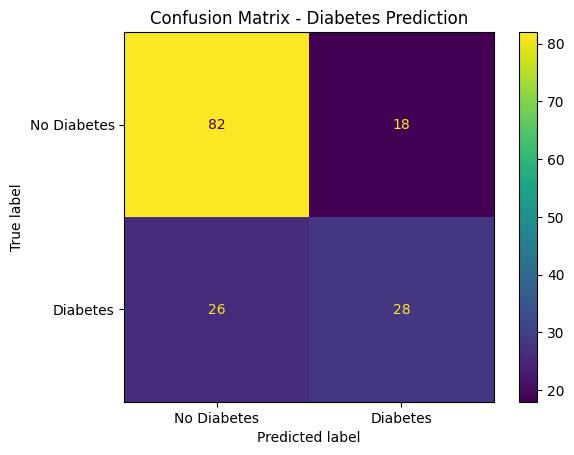

In [26]:
# ============================================
# FINAL VISUALIZATION: CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create and display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Confusion Matrix - Diabetes Prediction")
plt.show()